# **Proyecto de NLP- Analisis de sentimientos**

*Modelo distilbert-base-uncased-finetuned-sst-2-english*

In [21]:
!pip install -q transformers datasets evaluate scikit-learn pandas torch huggingface_hub

!pip install -U datasets huggingface_hub

In [22]:
#celda 3 y 2
import torch

device = 0 if torch.cuda.is_available() else -1

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Usando CPU")



from huggingface_hub import notebook_login

notebook_login()

GPU disponible: True
GPU: Tesla T4


In [23]:
#4
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print(dataset["test"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
{'text': 'I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn\'t match the background, and painfully one-dimensional characters cannot be overcome with a \'sci-fi\' setting. (I\'m sure there are those of you out there who think Babylon 5 is good sci-fi TV. It\'s not. It\'s clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat im

In [24]:
#celda 5

import pandas as pd

sample_size = 150

data = dataset["test"].shuffle(seed=42).select(range(sample_size))

texts = data["text"]
true_labels = data["label"]  # 0 = negativo, 1 = positivo

df = pd.DataFrame({
    "text": texts,
    "true_label": true_labels
})

df.head()

,text,true_label
0,<br /><br />When I unsuspectedly rented A Thou...,1
1,This is the latest entry in the long series of...,1
2,This movie was so frustrating. Everything seem...,0
3,"I was truly and wonderfully surprised at ""O' B...",1
4,This movie spends most of its time preaching t...,0


In [25]:
#Celda 6

models = {
    "DistilBERT SST-2": "distilbert-base-uncased-finetuned-sst-2-english",
    "BERT SST-2": "textattack/bert-base-uncased-SST-2",
    "RoBERTa Twitter": "cardiffnlp/twitter-roberta-base-sentiment-latest"
}

In [26]:
#celda 7

def normalize_label(output):
    label = output["label"].lower()

    if label in ["positive", "pos", "label_1"]:
        return 1

    if label in ["negative", "neg", "label_0"]:
        return 0

    # RoBERTa Twitter puede tener neutral.
    # Para SST-2 solo necesitamos positivo/negativo.
    if "positive" in label:
        return 1

    if "negative" in label:
        return 0

    # Si el modelo devuelve neutral, se fuerza a negativo como fallback.
    return 0

In [27]:
#celda 8

import time
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
predictions_by_model = {}

for model_name, model_id in models.items():
    print(f"\nEvaluando modelo: {model_name}")
    print(f"Modelo Hugging Face: {model_id}")

    #classifier = pipeline(
    #    task="sentiment-analysis",
    #    model=model_id,
    #    tokenizer=model_id,
    #    device=device,
    #    truncation=True
    #)
    classifier = pipeline(
    task="sentiment-analysis",
    model=model_id,
    tokenizer=model_id,
    device=-1,          # Forzar CPU para evitar error CUDA
    truncation=True,
    max_length=512
    )



    y_pred = []
    latencies = []

    for text in texts:
        start_time = time.time()
        output = classifier(text)[0]
        end_time = time.time()

        pred_label = normalize_label(output)

        y_pred.append(pred_label)
        latencies.append(end_time - start_time)

    acc = accuracy_score(true_labels, y_pred)
    precision = precision_score(true_labels, y_pred, zero_division=0)
    recall = recall_score(true_labels, y_pred, zero_division=0)
    f1 = f1_score(true_labels, y_pred, zero_division=0)
    avg_latency = sum(latencies) / len(latencies)

    results.append({
        "Modelo": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Latencia promedio (s)": avg_latency
    })

    predictions_by_model[model_name] = y_pred

results_df = pd.DataFrame(results)
results_df


Evaluando modelo: DistilBERT SST-2
Modelo Hugging Face: distilbert-base-uncased-finetuned-sst-2-english


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Evaluando modelo: BERT SST-2
Modelo Hugging Face: textattack/bert-base-uncased-SST-2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Evaluando modelo: RoBERTa Twitter
Modelo Hugging Face: cardiffnlp/twitter-roberta-base-sentiment-latest


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Modelo,Accuracy,Precision,Recall,F1-score,Latencia promedio (s)
0,DistilBERT SST-2,0.860000,0.890625,0.802817,0.844444,0.362117
1,BERT SST-2,0.893333,0.887324,0.887324,0.887324,0.532472
2,RoBERTa Twitter,0.826667,0.924528,0.690141,0.790323,0.539866


In [28]:
#cwelda 9

results_df_sorted = results_df.sort_values(by="F1-score", ascending=False)

results_df_sorted

,Modelo,Accuracy,Precision,Recall,F1-score,Latencia promedio (s)
1,BERT SST-2,0.893333,0.887324,0.887324,0.887324,0.532472
0,DistilBERT SST-2,0.860000,0.890625,0.802817,0.844444,0.362117
2,RoBERTa Twitter,0.826667,0.924528,0.690141,0.790323,0.539866


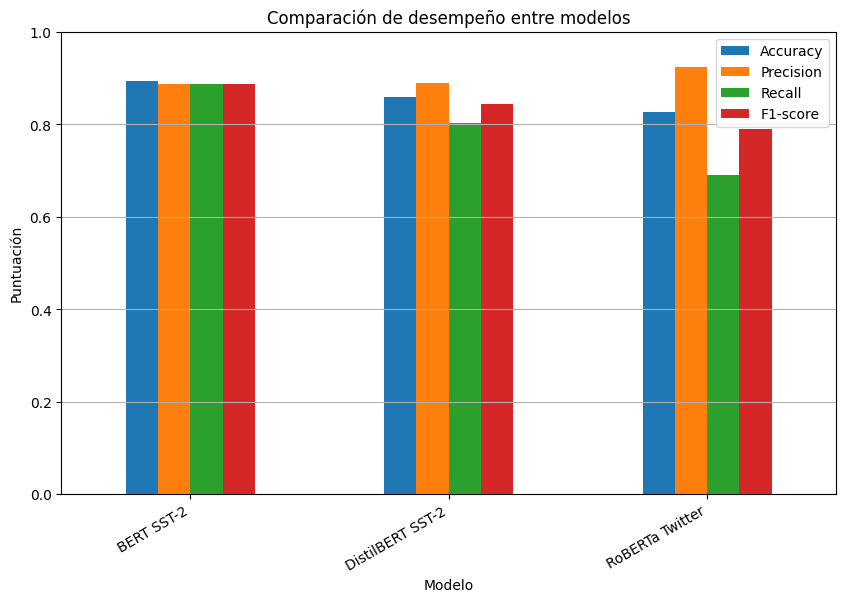

In [29]:
#celda 10

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

results_df_sorted.set_index("Modelo")[metrics].plot(kind="bar", figsize=(10, 6))

plt.title("Comparación de desempeño entre modelos")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

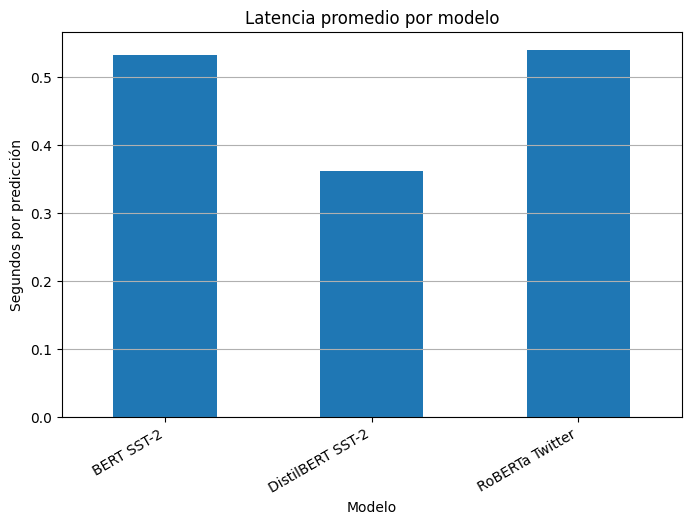

In [30]:
#celda 11

results_df_sorted.set_index("Modelo")["Latencia promedio (s)"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Latencia promedio por modelo")
plt.ylabel("Segundos por predicción")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()


In [32]:
#celda 12

test_sentences = [
    "The service was excellent and the product arrived on time.",
    "I am very disappointed with the quality of this product.",
    "The experience was acceptable but not amazing."
]

for model_name, model_id in models.items():
    print(f"\nModelo: {model_name}")
    #classifier = pipeline(
    #    task="sentiment-analysis",
    #    model=model_id,
    #    tokenizer=model_id,
    #    device=device,
    #    truncation=True
    #)
    classifier = pipeline(
    task="sentiment-analysis",
    model=model_id,
    tokenizer=model_id,
    device=-1,
    truncation=True,
    max_length=512
    )

    for sentence in test_sentences:
        print(sentence)
        print(classifier(sentence)[0])


Modelo: DistilBERT SST-2


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

The service was excellent and the product arrived on time.
{'label': 'POSITIVE', 'score': 0.9996527433395386}
I am very disappointed with the quality of this product.
{'label': 'NEGATIVE', 'score': 0.999798595905304}
The experience was acceptable but not amazing.
{'label': 'NEGATIVE', 'score': 0.989382266998291}

Modelo: BERT SST-2


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The service was excellent and the product arrived on time.
{'label': 'LABEL_1', 'score': 0.999352753162384}
I am very disappointed with the quality of this product.
{'label': 'LABEL_0', 'score': 0.9991126656532288}
The experience was acceptable but not amazing.
{'label': 'LABEL_0', 'score': 0.9498370289802551}

Modelo: RoBERTa Twitter


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The service was excellent and the product arrived on time.
{'label': 'positive', 'score': 0.9787902235984802}
I am very disappointed with the quality of this product.
{'label': 'negative', 'score': 0.9400156140327454}
The experience was acceptable but not amazing.
{'label': 'negative', 'score': 0.7624192833900452}
